## Loading Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
#uncomment this code for google colab
#from google.colab import files
#uploaded = files.upload()

In [8]:
hr_df = pd.read_csv('HR_Data.csv')

In [10]:
hr_df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
1291,0.10,0.90,6,272,5,0,1,0,RandD,low
5948,0.74,0.83,4,142,3,0,0,0,IT,medium
7776,0.83,0.90,3,179,2,1,0,0,product_mng,low
6423,0.36,0.69,3,165,3,0,0,0,sales,medium
12995,0.13,0.62,5,268,3,0,0,0,sales,medium
4605,0.85,0.57,5,210,3,0,0,0,sales,low
4505,0.77,0.79,3,157,3,0,0,1,sales,medium
9953,0.75,0.95,4,177,3,0,0,0,accounting,low
13684,0.28,0.59,6,281,3,0,0,0,product_mng,medium
1220,0.36,0.52,2,137,3,0,1,0,marketing,low


In [12]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Building a Classification Model

First we will build a model with *satisfaction level* with *left*.

### Setting X and y Values

In [15]:
X = hr_df[['satisfaction_level']]
y = hr_df.left

### Split Dataset into train and test

- Train: 80%
- Test: 20%

In [18]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, \
y_train, y_test = train_test_split( X,
                                    y,
                                    test_size = 0.2,
                                    random_state = 100 )

In [22]:
X_train.shape

(11999, 1)

In [24]:
X_test.shape

(3000, 1)

### Build Logistic Regression Model

In [27]:
from sklearn.linear_model import LogisticRegression

In [29]:
logreg_v1 = LogisticRegression(random_state=100)

In [31]:
logreg_v1.fit( X_train, y_train )

LogisticRegression(random_state=100)

### Finding Parameters

In [34]:
logreg_v1.intercept_

array([0.90010582])

In [36]:
logreg_v1.coef_

array([[-3.71760949]])

In [38]:
y_pred = logreg_v1.predict(X_test)

In [40]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [42]:
y_df.sample(10, random_state=20)

,actual,predicted
310,1,1
14670,1,0
1322,1,0
3314,0,0
11348,0,1
12630,1,1
7293,0,0
13600,0,1
4038,0,0
1499,1,0


### Measuring Accuracy

In [45]:
from sklearn.metrics import accuracy_score

In [47]:
accuracy_score(y_test, y_pred)

0.7683333333333333

# Evaluating Classification Models

## Confusion Matrix

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [53]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [55]:
cm

array([[ 209,  541],
       [ 154, 2096]])

In [57]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['Left', 'No Left'])

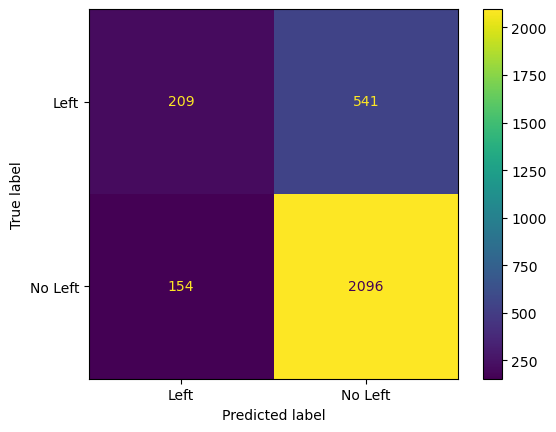

In [59]:
cm_plot.plot();

# Model is not great because FP is more - people leaving are not predicted correctly hence it is important

### Which failures are costly: False Positives or False Negatives?

#### Identify which failures are costly in each of the below scenarios.

- Building a classification model for loan approval? If the loan applicant will default a loan or not default a loan.
- false negative is dangerous: not deault was actually a default
- Building a classification model for detecting spam mails? If the mail is a spam mail or not.
- false positive is dangerous: not spam classified as spam

### What are different accuracy measures?

**Total Accuracy** 

**Precision** 

**True Positive Rate (TPR) or Recall or Sensitivity** 

**True Negative Rate (TNR) or Specificity** 

**F-Score (F-Measure)** - very important when both are important. Eg: any medical report

### Finding accuracy metrices

In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [70]:
recall_score(y_df.actual, y_df.predicted)

0.2786666666666667

In [72]:
precision_score(y_df.actual, y_df.predicted)

0.5757575757575758

In [74]:
f1_score(y_df.actual, y_df.predicted)

0.3755615453728661

In [76]:
print(classification_report(y_df.actual, y_df.predicted))

# We only look at "1" value - here the recall is bad!

              precision    recall  f1-score   support

           0       0.79      0.93      0.86      2250
           1       0.58      0.28      0.38       750

    accuracy                           0.77      3000
   macro avg       0.69      0.61      0.62      3000
weighted avg       0.74      0.77      0.74      3000



## How to evaluate and compare models?

In [79]:
y_pred_probs = logreg_v1.predict_proba(X_test)

In [81]:
y_pred_probs[0:5]

array([[0.85527319, 0.14472681],
       [0.93050335, 0.06949665],
       [0.61666336, 0.38333664],
       [0.8642357 , 0.1357643 ],
       [0.39727876, 0.60272124]])

In [83]:
y_pred_probs[:, 1]

array([0.14472681, 0.06949665, 0.38333664, ..., 0.26975321, 0.22812453,
       0.06949665])

In [85]:
y_df['pred_probs'] = y_pred_probs[:, 1]

In [87]:
y_df.sample(10, random_state=20)

,actual,predicted,pred_probs
310,1,1,0.629097
14670,1,0,0.357338
1322,1,0,0.119242
3314,0,0,0.149390
11348,0,1,0.593786
12630,1,1,0.629097
7293,0,0,0.062622
13600,0,1,0.575735
4038,0,0,0.115392
1499,1,0,0.323958


### Finding the probability distribution of predicted probabilities

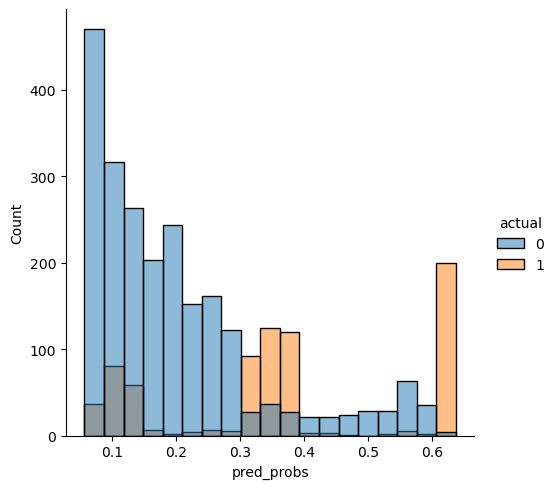

In [90]:
sn.displot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');

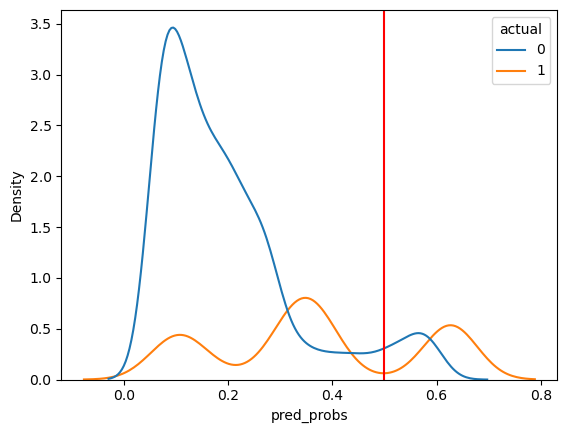

In [91]:
sn.kdeplot(data = y_df,
           x = 'pred_probs',
           hue = 'actual');
plt.axvline(x = 0.5, color = 'r', label = 'cut off');

### What happens if we change the cutoff probabilities?

- What happens if cutoff probability is 0.0
- What happens if cutoff probability is 1.0

In [113]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

In [115]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.7709238518518519

AttributeError: 'RocCurveDisplay' object has no attribute 'plots'

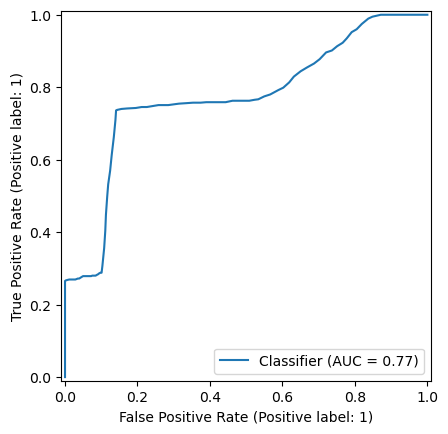

In [123]:
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs).plots();

### Changing the cutoff probabilities

In [138]:
y_df['new_preds'] = y_df.pred_probs.map(lambda x: 1 if x > 0.70 else 0)

In [140]:
cm_new = confusion_matrix(y_df.actual, y_df.new_preds, labels = [1,0])

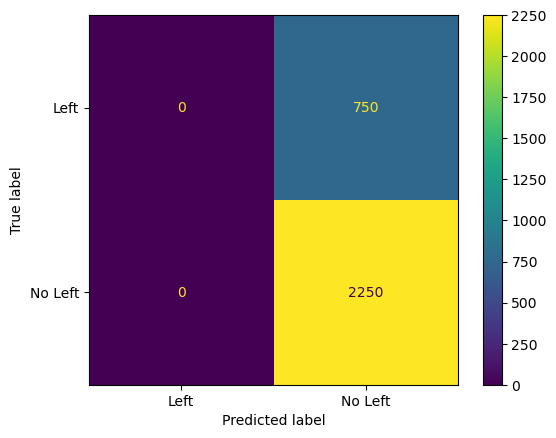

In [142]:
ConfusionMatrixDisplay(cm_new, display_labels=['Left', 'No Left']).plot();

In [144]:
print(classification_report(y_df.actual, y_df.new_preds))

              precision    recall  f1-score   support

           0       0.75      1.00      0.86      2250
           1       0.00      0.00      0.00       750

    accuracy                           0.75      3000
   macro avg       0.38      0.50      0.43      3000
weighted avg       0.56      0.75      0.64      3000



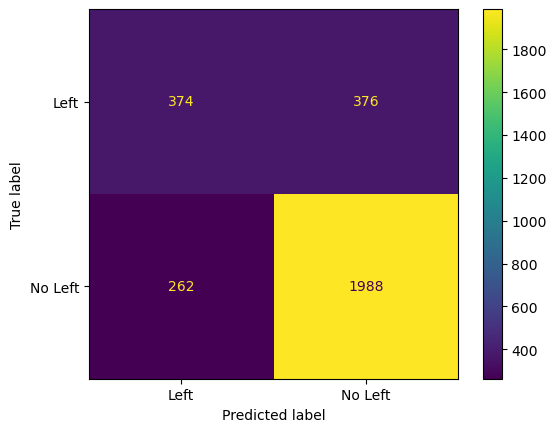

In [146]:
y_df['new_preds'] = y_df.pred_probs.map(lambda x: 1 if x > 0.35 else 0)
cm_new = confusion_matrix(y_df.actual, y_df.new_preds, labels = [1,0])
ConfusionMatrixDisplay(cm_new, display_labels=['Left', 'No Left']).plot();

In [148]:
print(classification_report(y_df.actual, y_df.new_preds))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      2250
           1       0.59      0.50      0.54       750

    accuracy                           0.79      3000
   macro avg       0.71      0.69      0.70      3000
weighted avg       0.78      0.79      0.78      3000



### Exercise:

- Build a logistic regression model with all the variables and left
- Compute RoC AUC and draw the curve
- Compute confusion and draw the confusion matrix